**Cell 1 — First look, zero assumptions.** Load the CSV, print shape/columns/dtypes/one full row. Goal: see what data actually exists before writing any logic.

In [1]:
# Cell 1 — Load the CSV and look at it with zero assumptions
import pandas as pd

CSV_PATH = "D:/DeepSense_V2V/data/scenario36.csv"   # adjust if yours differs

df = pd.read_csv(CSV_PATH)

print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nFirst row, fully expanded (so nothing gets truncated):")
pd.set_option('display.max_colwidth', None)
print(df.iloc[0])

Shape (rows, columns): (24799, 58)

Column names:
['abs_index', 'timestamp', 'seq_index', 'unit1_gps1', 'unit1_gps1_lat', 'unit1_gps1_lon', 'unit1_gps1_altitude', 'unit1_gps1_hdop', 'unit1_gps1_pdop', 'unit1_gps1_vdop', 'unit1_rgb1', 'unit1_rgb2', 'unit1_rgb3', 'unit1_rgb4', 'unit1_rgb5', 'unit1_rgb6', 'unit1_pwr1', 'unit1_pwr1_best-beam', 'unit1_pwr1_max-pwr', 'unit1_pwr1_min-pwr', 'unit1_pwr2', 'unit1_pwr2_best-beam', 'unit1_pwr2_max-pwr', 'unit1_pwr2_min-pwr', 'unit1_pwr3', 'unit1_pwr3_best-beam', 'unit1_pwr3_max-pwr', 'unit1_pwr3_min-pwr', 'unit1_pwr4', 'unit1_pwr4_best-beam', 'unit1_pwr4_max-pwr', 'unit1_pwr4_min-pwr', 'unit1_radar1', 'unit1_radar2', 'unit1_radar3', 'unit1_radar4', 'unit1_lidar1', 'unit2_gps1', 'unit2_gps1_lat', 'unit2_gps1_lon', 'unit2_gps1_altitude', 'unit2_gps1_hdop', 'unit2_gps1_pdop', 'unit2_gps1_vdop', 'satellite_img', 'unit1_pwr1_best-beam_v2', 'unit1_pwr1_max-pwr_v2', 'unit1_pwr1_min-pwr_v2', 'unit1_pwr2_best-beam_v2', 'unit1_pwr2_max-pwr_v2', 'unit1_pwr2_

**Cell 2 — Find the real file paths.** The CSV's relative paths didn't resolve from the folder we guessed; this walks the actual folder tree to find where `unit1/` really lives (inside `scenario36/`).

In [4]:
# Cell 2 (revised again) — Look inside the scenario36 subfolder

import os

scenario_dir = "D:/DeepSense_V2V/data/scenario36"

print("Contents of scenario36 folder:")
for item in os.listdir(scenario_dir):
    print(" ", item)

# Now retry building the full path using this as the root
rel_path = df.loc[0, "unit1_pwr1"]
full_guess = os.path.join(scenario_dir, rel_path)
print("\nGuessed full path:", full_guess)
print("Does it exist?", os.path.exists(full_guess))

Contents of scenario36 folder:
  unit1
  unit2

Guessed full path: D:/DeepSense_V2V/data/scenario36\unit1/pwr1/pwr_11-46-30.559536.txt
Does it exist? True


**Cell 3 — Raw power file + `_v2` column check.** Opens one actual `.txt` power file to see real units, and diffs every `_v2` column against its original across all rows. Result: values are linear (not dB), and `_v2` columns are 100% identical to originals everywhere.

In [5]:
# Cell 3 — Inspect a raw power file directly, and check if _v2 columns ever differ

DATA_ROOT = "D:/DeepSense_V2V/data/scenario36"

# 3a. Open one actual pwr .txt file and print its raw contents
sample_pwr_path = os.path.join(DATA_ROOT, df.loc[0, "unit1_pwr1"])
with open(sample_pwr_path, "r") as f:
    raw_lines = f.readlines()

print("Power file path:", sample_pwr_path)
print("Number of lines/values in file:", len(raw_lines))
print("First 10 raw values:")
print(raw_lines[:10])
print("Last 5 raw values:")
print(raw_lines[-5:])

# 3b. Check whether _v2 columns ever differ from the original columns, across ALL rows
diff_report = {}
for i in range(1, 5):
    for suffix in ["best-beam", "max-pwr", "min-pwr"]:
        col_orig = f"unit1_pwr{i}_{suffix}"
        col_v2 = f"unit1_pwr{i}_{suffix}_v2"
        n_diff = (df[col_orig] != df[col_v2]).sum()
        diff_report[f"pwr{i}_{suffix}"] = n_diff

print("\nNumber of rows where _v2 differs from original, per column:")
for k, v in diff_report.items():
    print(f"  {k}: {v} / {len(df)} rows differ")

Power file path: D:/DeepSense_V2V/data/scenario36\unit1/pwr1/pwr_11-46-30.559536.txt
Number of lines/values in file: 64
First 10 raw values:
['1.275473041459918022e-04\n', '2.142616722267121077e-04\n', '1.808271335903555155e-04\n', '2.262457419419661164e-04\n', '2.117887925123795867e-04\n', '2.057303063338622451e-04\n', '2.214003179688006639e-04\n', '2.364807151025161147e-04\n', '1.688098709564656019e-04\n', '2.741923672147095203e-04\n']
Last 5 raw values:
['1.775482669472694397e-04\n', '1.779327722033485770e-04\n', '1.704717869870364666e-04\n', '1.754029799485579133e-04\n', '1.502060185885056853e-04\n']

Number of rows where _v2 differs from original, per column:
  pwr1_best-beam: 0 / 24799 rows differ
  pwr1_max-pwr: 0 / 24799 rows differ
  pwr1_min-pwr: 0 / 24799 rows differ
  pwr2_best-beam: 0 / 24799 rows differ
  pwr2_max-pwr: 0 / 24799 rows differ
  pwr2_min-pwr: 0 / 24799 rows differ
  pwr3_best-beam: 0 / 24799 rows differ
  pwr3_max-pwr: 0 / 24799 rows differ
  pwr3_min-pwr: 0

**Cell 4 — Confirm label construction.** Checks that `best-beam` = argmax of the raw file, and `overall-beam` = argmax of the 4 arrays concatenated (pwr1→pwr2→pwr3→pwr4). Both confirmed exactly — the 256-way label logic is solid.

In [6]:
# Cell 4 — Understand the 64-value beam array, and how 4 arrays -> one label

import numpy as np

# 4a. Does argmax of the raw file match the CSV's recorded best-beam?
raw_vals = np.array([float(v) for v in raw_lines])
print("File length:", len(raw_vals))
print("Argmax index in file (0-indexed):", raw_vals.argmax())
print("CSV unit1_pwr1_best-beam for this row:", df.loc[0, "unit1_pwr1_best-beam"])

# 4b. Load all 4 pwr files for row 0 and check the overall-beam arithmetic
all_four = []
for i in range(1, 5):
    p = os.path.join(DATA_ROOT, df.loc[0, f"unit1_pwr{i}"])
    with open(p, "r") as f:
        vals = np.array([float(v) for v in f.readlines()])
    all_four.append(vals)
    print(f"pwr{i}: len={len(vals)}, argmax={vals.argmax()}, max_val={vals.max():.6e}")

concat = np.concatenate(all_four)
print("\nConcatenated length:", len(concat))
print("Argmax of concatenated array:", concat.argmax())
print("CSV unit1_overall-beam for this row:", df.loc[0, "unit1_overall-beam"])

File length: 64
Argmax index in file (0-indexed): 14
CSV unit1_pwr1_best-beam for this row: 14
pwr1: len=64, argmax=14, max_val=3.527603e-04
pwr2: len=64, argmax=43, max_val=4.678775e-04
pwr3: len=64, argmax=34, max_val=4.040673e-01
pwr4: len=64, argmax=61, max_val=1.846578e-04

Concatenated length: 256
Argmax of concatenated array: 162
CSV unit1_overall-beam for this row: 162


**Cell 5 — Is one antenna panel usually strongest?** Compares max power across pwr1-4 per row. Result: pwr1 wins 58.8%, pwr3 34.1%, pwr2 5.3%, pwr4 1.8% — a strong, systematic imbalance, not noise.

In [7]:
# Cell 5 — Is the pwr3-dominant pattern a one-off, or systematic across the dataset?

import numpy as np

# Use the CSV's own max-pwr summary columns (already confirmed == argmax file values) 
# across ALL rows, no need to re-read every file
max_cols = ["unit1_pwr1_max-pwr", "unit1_pwr2_max-pwr", "unit1_pwr3_max-pwr", "unit1_pwr4_max-pwr"]
maxes = df[max_cols]

print("Summary stats of max-power per array, across all 24,799 rows:")
print(maxes.describe())

print("\nHow often is each array the strongest (has the overall max) per row?")
strongest_array = maxes.values.argmax(axis=1) + 1   # 1-indexed to match pwr1-4
vals, counts = np.unique(strongest_array, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  pwr{v} is strongest in {c} / {len(df)} rows ({100*c/len(df):.1f}%)")

# Also convert overall-beam to figure out which quadrant (1-4) it falls in, per row, 
# and cross check against 'strongest array' logic above
quadrant_from_overall = (df["unit1_overall-beam"] // 64) + 1
print("\nWhich quadrant unit1_overall-beam falls into, across all rows:")
print(quadrant_from_overall.value_counts().sort_index())

Summary stats of max-power per array, across all 24,799 rows:
       unit1_pwr1_max-pwr  unit1_pwr2_max-pwr  unit1_pwr3_max-pwr  \
count        24799.000000        24799.000000        24799.000000   
mean             0.042040            0.005089            0.052132   
std              0.116794            0.055071            0.124262   
min              0.000142            0.000151            0.000123   
25%              0.000208            0.000170            0.000139   
50%              0.001207            0.000198            0.000171   
75%              0.012868            0.000420            0.035567   
max              0.757862            1.050527            0.952910   

       unit1_pwr4_max-pwr  
count        24799.000000  
mean             0.004317  
std              0.045688  
min              0.000123  
25%              0.000150  
50%              0.000174  
75%              0.000297  
max              0.806242  

How often is each array the strongest (has the overall max) per

**Cell 6 — Does bearing explain panel choice?** Computes relative bearing of unit2 vs unit1 from GPS and groups it by which panel won. (Note: `.describe()` here is misleading for circular data — see Cell 7.)

In [8]:
# Cell 6 — Does relative bearing (unit2 vs unit1) explain which panel is strongest?

import numpy as np

# Convert lat/lon degrees to approximate local flat-earth meters (fine for short V2V ranges)
lat0 = np.radians(df["unit1_gps1_lat"])
dlat = np.radians(df["unit2_gps1_lat"] - df["unit1_gps1_lat"])
dlon = np.radians(df["unit2_gps1_lon"] - df["unit1_gps1_lon"])

R = 6371000  # Earth radius in meters
rel_north = dlat * R
rel_east = dlon * R * np.cos(lat0)

# Bearing of unit2 relative to unit1, in degrees [0, 360)
bearing = (np.degrees(np.arctan2(rel_east, rel_north)) + 360) % 360

# Reuse "strongest_array" computed in Cell 5 (1-4)
import pandas as pd
bearing_df = pd.DataFrame({"bearing_deg": bearing, "strongest_array": strongest_array})

print("Bearing (degrees) summary, grouped by which array is strongest:")
print(bearing_df.groupby("strongest_array")["bearing_deg"].describe())

Bearing (degrees) summary, grouped by which array is strongest:
                   count        mean         std       min         25%  \
strongest_array                                                          
1                14588.0  190.262340   92.802134  0.000000  153.337780   
2                 1304.0  260.636576   78.636540  0.004733  250.836890   
3                 8463.0  182.611948  124.141120  0.000000   27.405914   
4                  444.0   97.430603   52.533707  0.102413   71.320461   

                        50%         75%         max  
strongest_array                                      
1                180.146223  263.482258  359.996704  
2                269.782971  270.732249  359.997461  
3                183.577060  272.467375  359.980178  
4                 98.979825  108.121479  359.848115  


**Cell 7 — Bearing histograms (correct way).** Polar histograms per panel, avoiding the circular-mean distortion from Cell 6. Confirms panel choice is geometric: each panel dominates a distinct compass direction.

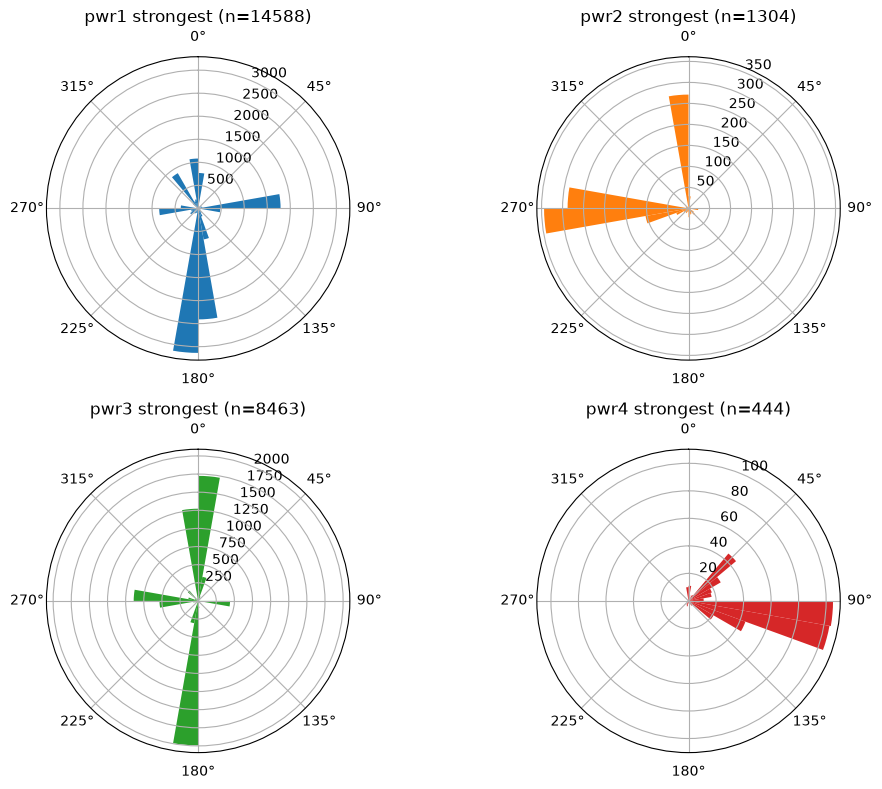

In [9]:
# Cell 7 — Histogram of bearing per strongest-array group (avoids circular-mean distortion)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8), subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for idx, arr_num in enumerate([1, 2, 3, 4]):
    mask = bearing_df["strongest_array"] == arr_num
    theta = np.radians(bearing_df.loc[mask, "bearing_deg"])
    axes[idx].hist(theta, bins=36, color=f"C{idx}")
    axes[idx].set_title(f"pwr{arr_num} strongest (n={mask.sum()})")
    axes[idx].set_theta_zero_location("N")
    axes[idx].set_theta_direction(-1)

plt.tight_layout()
plt.show()

**Cell 8 — Real GPS trajectory shape.** Scatter plot of both vehicles' raw lat/lon. Reveals the route is several disconnected street segments, not one simple road — explains the bimodal bearing patterns from Cell 7.

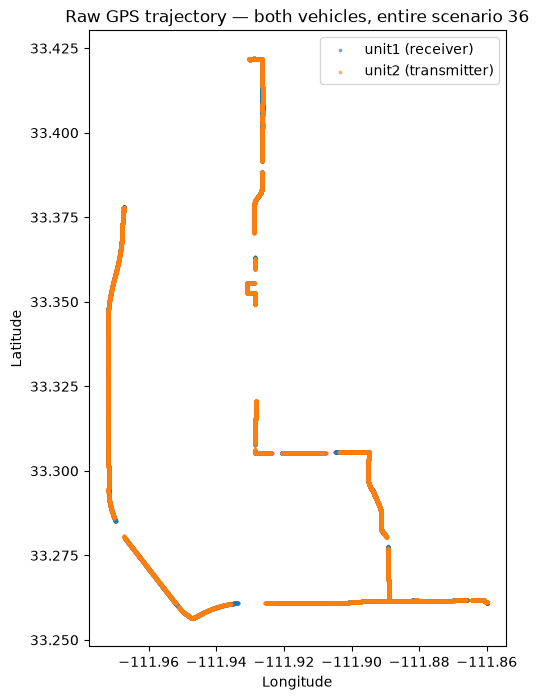

Number of distinct seq_index values: 124

Row count per seq_index (first 20):
seq_index
1     200
2     200
3     200
4     200
5     200
6     200
7     200
8     200
10    200
11    200
12    200
13    200
14    200
15    200
16    200
17    200
18    200
19    200
20    200
21    200
Name: count, dtype: int64


In [10]:
# Cell 8 — Plot the actual GPS trajectory (unit1 and unit2) to see the real road shape

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df["unit1_gps1_lon"], df["unit1_gps1_lat"], s=3, label="unit1 (receiver)", alpha=0.5)
ax.scatter(df["unit2_gps1_lon"], df["unit2_gps1_lat"], s=3, label="unit2 (transmitter)", alpha=0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Raw GPS trajectory — both vehicles, entire scenario 36")
ax.legend()
ax.set_aspect("equal")
plt.show()

# Also: how many distinct driving runs (seq_index) are there, and how long is each?
print("Number of distinct seq_index values:", df["seq_index"].nunique())
print("\nRow count per seq_index (first 20):")
print(df["seq_index"].value_counts().sort_index().head(20))

**Cell 9 — Color by run, check ordering.** Colors the trajectory by `seq_index` and verifies `seq_index` is already chronologically ordered (matches `abs_index`). Also finds the one 199-row run (vs. 200 for all others).

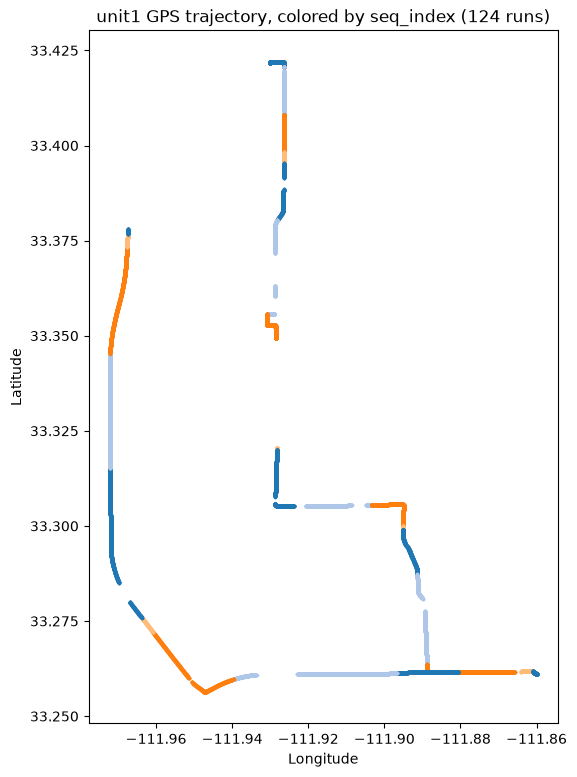

Is seq_index already sorted by first-appearance abs_index?  True

Runs with row count != 200:
seq_index
137    199
Name: count, dtype: int64


In [12]:
# Cell 9 (fixed) — Color trajectory by seq_index, and check if seq_index order matches abs_index order

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 9))
seq_ids = sorted(df["seq_index"].unique())
colors = plt.get_cmap("tab20", len(seq_ids))

for i, sid in enumerate(seq_ids):
    sub = df[df["seq_index"] == sid]
    ax.plot(sub["unit1_gps1_lon"], sub["unit1_gps1_lat"], '.', markersize=3, color=colors(i % 20))

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("unit1 GPS trajectory, colored by seq_index (124 runs)")
ax.set_aspect("equal")
plt.show()

# Does seq_index order match abs_index (time) order? i.e. is seq_index monotonic in time?
first_abs_per_seq = df.groupby("seq_index")["abs_index"].min().sort_index()
print("Is seq_index already sorted by first-appearance abs_index? ",
      (first_abs_per_seq.values == sorted(first_abs_per_seq.values)).all())

# Row count check - find the run that isn't exactly 200 rows
counts = df["seq_index"].value_counts().sort_index()
print("\nRuns with row count != 200:")
print(counts[counts != 200])

**Cell 10 — Chronological run order vs. physical location.** Lists every run in true time order next to its rounded lat/lon cluster. This is the evidence base for the split-leakage check in Cell 11.

In [13]:
# Cell 10 — Does the physical location visited change systematically over time?

# For each seq_index (run), get its mean location and its first abs_index (=time order)
run_summary = df.groupby("seq_index").agg(
    mean_lat=("unit1_gps1_lat", "mean"),
    mean_lon=("unit1_gps1_lon", "mean"),
    first_abs=("abs_index", "min")
).sort_values("first_abs").reset_index()

# Cluster runs into rough physical groups using simple rounding (bins of ~0.005 deg ~ 500m)
run_summary["loc_cluster"] = (
    run_summary["mean_lat"].round(2).astype(str) + "_" + run_summary["mean_lon"].round(2).astype(str)
)

print("Number of distinct rough location clusters:", run_summary["loc_cluster"].nunique())

# Now: in chronological order, which cluster does each run belong to?
print("\nRun order (chronological) -> location cluster:")
print(run_summary[["seq_index", "first_abs", "loc_cluster"]].to_string(index=False))

Number of distinct rough location clusters: 39

Run order (chronological) -> location cluster:
 seq_index  first_abs   loc_cluster
         1       2674 33.42_-111.93
         2       2874 33.42_-111.93
         3       3074 33.42_-111.93
         4       3274 33.42_-111.93
         5       3474 33.42_-111.93
         6       3674 33.42_-111.93
         7       3874 33.42_-111.93
         8       4074 33.42_-111.93
        10       4474 33.42_-111.93
        11       4674 33.42_-111.93
        12       4874 33.41_-111.93
        13       5074 33.41_-111.93
        14       5274 33.41_-111.93
        15       5474 33.41_-111.93
        16       5674 33.41_-111.93
        17       5874 33.41_-111.93
        18       6074 33.41_-111.93
        19       6274  33.4_-111.93
        20       6474  33.4_-111.93
        21       6674  33.4_-111.93
        22       6874 33.39_-111.93
        24       7274 33.39_-111.93
        26       7674 33.39_-111.93
        28       8074 33.39_-111.93
     

**Cell 11 — Quantify the split-leakage bug.** Applies the pipeline's actual 55/15/15/15 chronological split and checks location-cluster overlap between train and test. Result: **0 of 8 test clusters ever appear in train** — confirms the root cause of model collapse.

In [14]:
# Cell 11 — Quantify train/test location overlap under the CURRENT chronological split

n = len(run_summary)
train_end = int(0.55 * n)
val_end = int(0.70 * n)
calib_end = int(0.85 * n)

train_runs = run_summary.iloc[:train_end]
val_runs = run_summary.iloc[train_end:val_end]
calib_runs = run_summary.iloc[val_end:calib_end]
test_runs = run_summary.iloc[calib_end:]

train_clusters = set(train_runs["loc_cluster"])
test_clusters = set(test_runs["loc_cluster"])

print(f"Train runs: {len(train_runs)}, Test runs: {len(test_runs)}")
print(f"Distinct location clusters in TRAIN: {len(train_clusters)}")
print(f"Distinct location clusters in TEST: {len(test_clusters)}")
print(f"Clusters in TEST that ALSO appear in TRAIN: {len(test_clusters & train_clusters)}")
print(f"Clusters in TEST NEVER seen in TRAIN: {len(test_clusters - train_clusters)}")
print("\nTest-only clusters (never in train):")
print(sorted(test_clusters - train_clusters))

Train runs: 68, Test runs: 19
Distinct location clusters in TRAIN: 16
Distinct location clusters in TEST: 8
Clusters in TEST that ALSO appear in TRAIN: 0
Clusters in TEST NEVER seen in TRAIN: 8

Test-only clusters (never in train):
['33.31_-111.97', '33.32_-111.97', '33.33_-111.97', '33.34_-111.97', '33.35_-111.97', '33.36_-111.97', '33.37_-111.97', '33.38_-111.97']


**Cell 12 — Look at rgb5 vs rgb6.** Side-by-side comparison for one sample. Both are forward-facing (not front/rear as assumed) — two overlapping wide-angle views from slightly different mount positions.

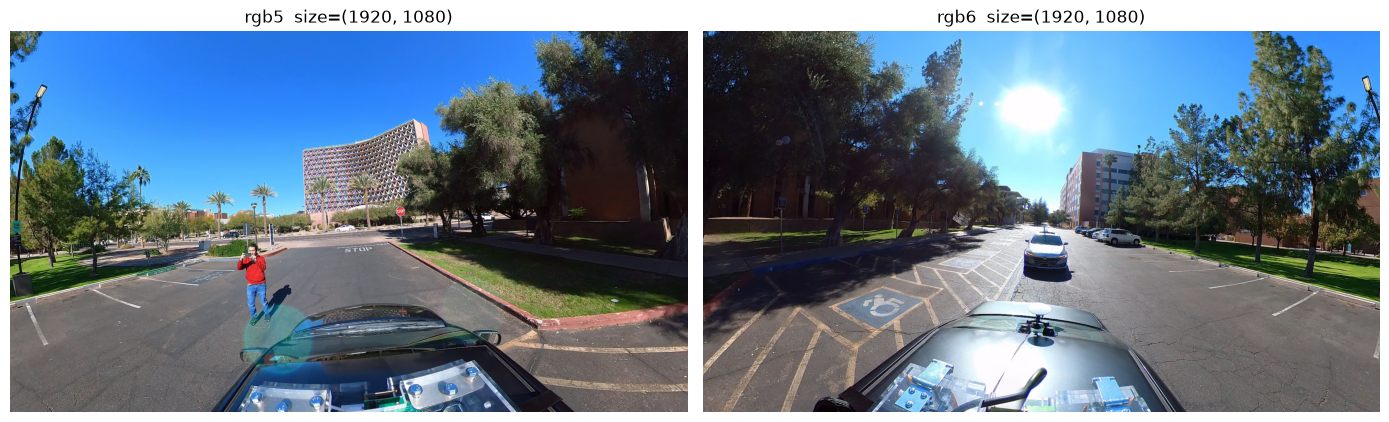

Timestamp: 11-46-31.214536


In [17]:
# Cell 12 (fixed) — Look at rgb5 and rgb6 for one sample, check resolution

from PIL import Image
import matplotlib.pyplot as plt

row = df.iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, cam in enumerate(["rgb5", "rgb6"]):
    rel_path = row[f"unit1_{cam}"]
    full_path = os.path.join(DATA_ROOT, rel_path)
    img = Image.open(full_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{cam}  size={img.size}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print("Timestamp:", row["timestamp"])

**Cell 13 — rgb5 vs rgb6 across multiple samples.** Checks whether rgb6 consistently shows the target vehicle better (it doesn't — sometimes rgb5 does instead). Confirms the two cameras carry genuinely complementary, not redundant, information.

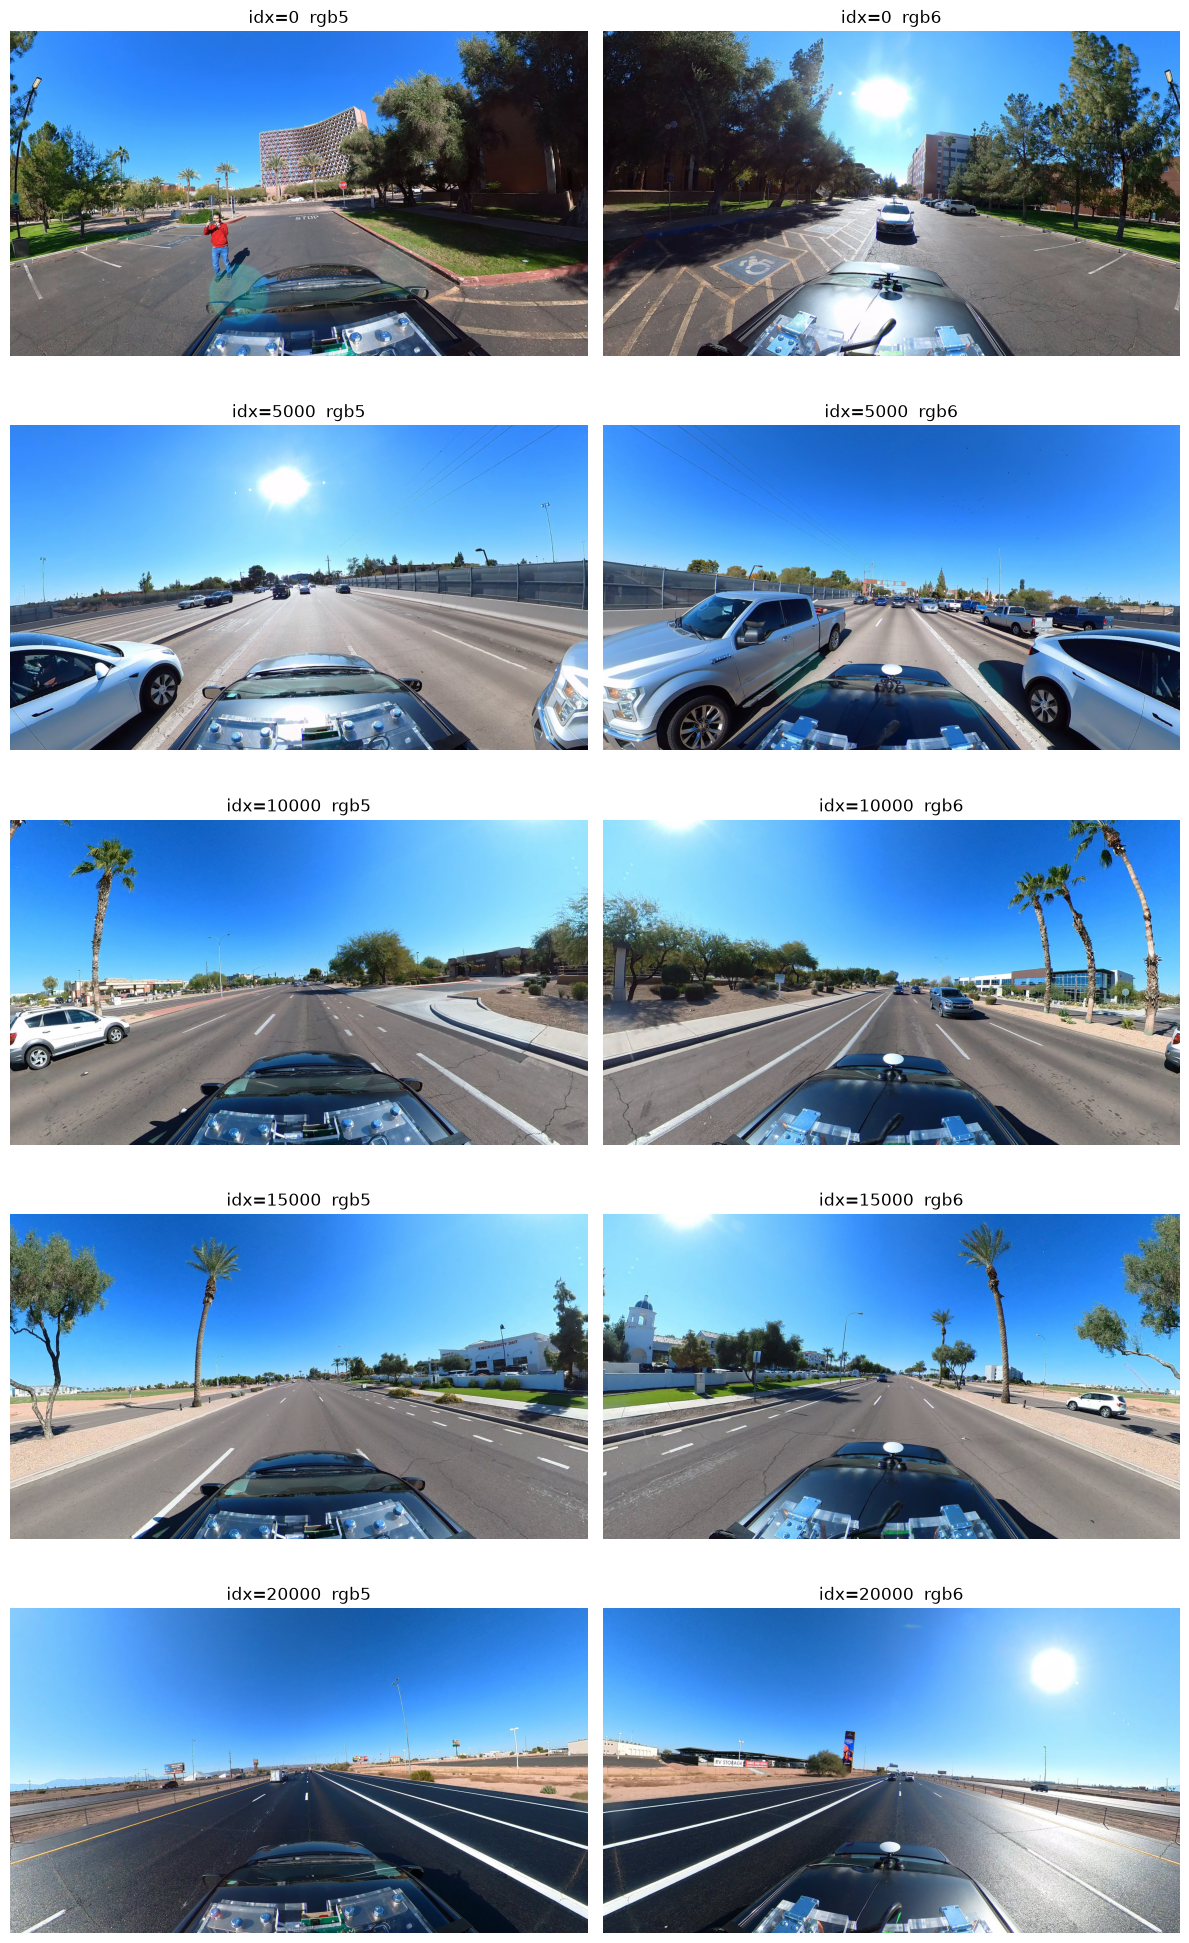

In [18]:
# Cell 13 — Look at rgb5/rgb6 for several different timestamps, spread across the dataset

import matplotlib.pyplot as plt

sample_idxs = [0, 5000, 10000, 15000, 20000]

fig, axes = plt.subplots(len(sample_idxs), 2, figsize=(12, 4*len(sample_idxs)))

for row_i, idx in enumerate(sample_idxs):
    row = df.iloc[idx]
    for col_i, cam in enumerate(["rgb5", "rgb6"]):
        full_path = os.path.join(DATA_ROOT, row[f"unit1_{cam}"])
        img = Image.open(full_path)
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"idx={idx}  {cam}")
        axes[row_i, col_i].axis("off")

plt.tight_layout()
plt.show()

**Cell 14 — Time-of-day / lighting check.** Extracts recording hour from every row's timestamp. Result: entire dataset recorded between 11:00–14:00, single lighting condition — no day/night domain gap to worry about.

Distribution of recording hour across all 24,799 rows:
timestamp
11     6121
12    10279
13     8399
Name: count, dtype: int64


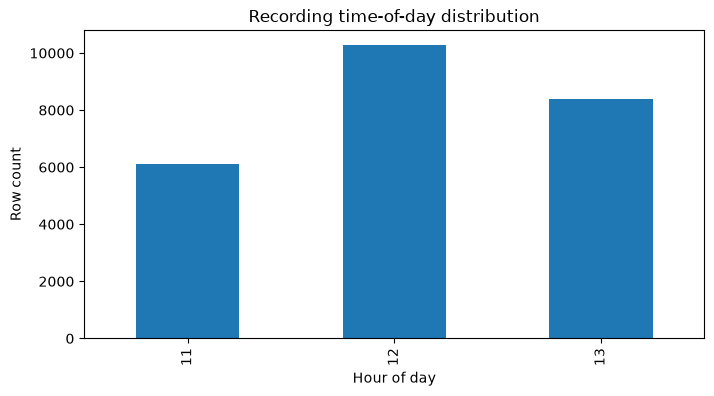

In [19]:
# Cell 14 — Check day/night / lighting variation across the FULL dataset via timestamps

import pandas as pd

# timestamp column looks like "HH-MM-SS.microseconds" (no date) — extract just the hour
hours = df["timestamp"].str.split("-").str[0].astype(int)

print("Distribution of recording hour across all 24,799 rows:")
print(hours.value_counts().sort_index())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
hours.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Row count")
plt.title("Recording time-of-day distribution")
plt.show()

**Cell 15 — GPS fix quality (HDOP/PDOP/VDOP).** unit1 is consistently clean; unit2 has a handful of high-HDOP rows worth checking further (done in Cell 16).

In [20]:
# Cell 15 — GPS quality: HDOP/PDOP/VDOP distributions for both vehicles

dop_cols_u1 = ["unit1_gps1_hdop", "unit1_gps1_pdop", "unit1_gps1_vdop"]
dop_cols_u2 = ["unit2_gps1_hdop", "unit2_gps1_pdop", "unit2_gps1_vdop"]

print("unit1 GPS quality (DOP values — lower is better, <1 excellent, 1-2 good, >5 poor):")
print(df[dop_cols_u1].describe())

print("\nunit2 GPS quality:")
print(df[dop_cols_u2].describe())

# Flag rows with notably poor GPS fix quality (common rule of thumb: HDOP > 2 is degraded)
poor_u1 = (df["unit1_gps1_hdop"] > 2).sum()
poor_u2 = (df["unit2_gps1_hdop"] > 2).sum()
print(f"\nRows with unit1 HDOP > 2 (degraded fix): {poor_u1} / {len(df)} ({100*poor_u1/len(df):.2f}%)")
print(f"Rows with unit2 HDOP > 2 (degraded fix): {poor_u2} / {len(df)} ({100*poor_u2/len(df):.2f}%)")

# Also check altitude - is it stable/plausible, or noisy (which would indicate a bad fix)
print("\nAltitude stats (unit1):")
print(df["unit1_gps1_altitude"].describe())

unit1 GPS quality (DOP values — lower is better, <1 excellent, 1-2 good, >5 poor):
       unit1_gps1_hdop  unit1_gps1_pdop  unit1_gps1_vdop
count     24799.000000     24799.000000     24799.000000
mean          0.528176         1.029173         0.882854
std           0.051780         0.087376         0.080015
min           0.460000         0.910000         0.740000
25%           0.510000         0.980000         0.840000
50%           0.520000         1.030000         0.890000
75%           0.550000         1.060000         0.900000
max           1.470000         2.440000         1.950000

unit2 GPS quality:
       unit2_gps1_hdop  unit2_gps1_pdop  unit2_gps1_vdop
count     24799.000000     24799.000000     24799.000000
mean          0.517092         0.993143         0.853719
std           0.912736         0.910171         0.911567
min           0.460000         0.870000         0.710000
25%           0.480000         0.920000         0.800000
50%           0.500000         0.970000   

**Cell 16 — Do the bad-HDOP rows actually corrupt coordinates?** Pulls up the 7 degraded unit2 fixes with their neighboring rows. Result: coordinates stay smooth and physically plausible throughout — false alarms, safe to ignore.

In [21]:
# Cell 16 — Isolate the degraded unit2 GPS fixes and check their real-world impact

bad_u2 = df[df["unit2_gps1_hdop"] > 2].copy()
print("The 7 degraded unit2 GPS rows:")
print(bad_u2[["abs_index", "seq_index", "unit2_gps1_hdop", "unit2_gps1_lat", "unit2_gps1_lon"]])

# For each bad row, compare its lat/lon to the row immediately before/after it (same seq_index)
# to see if the bad fix causes an implausible jump in position
for idx in bad_u2.index:
    seq = df.loc[idx, "seq_index"]
    neighbors = df[(df["seq_index"] == seq) & (df["abs_index"].between(df.loc[idx,"abs_index"]-3, df.loc[idx,"abs_index"]+3))]
    print(f"\n--- Context around abs_index={df.loc[idx,'abs_index']} (seq_index={seq}) ---")
    print(neighbors[["abs_index", "unit2_gps1_hdop", "unit2_gps1_lat", "unit2_gps1_lon"]])

The 7 degraded unit2 GPS rows:
       abs_index  seq_index  unit2_gps1_hdop  unit2_gps1_lat  unit2_gps1_lon
19951      27415        112        17.156667       33.275322     -111.963339
19952      27416        112        33.723333       33.275340     -111.963354
19953      27417        112        50.290000       33.275358     -111.963368
19954      27418        112        66.856667       33.275376     -111.963383
19955      27419        112        83.423333       33.275394     -111.963398
19956      27420        112        66.843333       33.275431     -111.963428
19957      27421        112        33.696667       33.275449     -111.963442

--- Context around abs_index=27415 (seq_index=112) ---
       abs_index  unit2_gps1_hdop  unit2_gps1_lat  unit2_gps1_lon
19948      27412         0.560000       33.275250     -111.963280
19949      27413         0.570000       33.275268     -111.963294
19950      27414         0.580000       33.275286     -111.963309
19951      27415        17.156667

**Cell 17 — THE FEASIBILITY GATE.** Loads all 256-beam profiles for every row, explicitly converts linear→dB, computes near-optimal set size at 1dB/3dB. Median is sharp (3-5 beams) but mean is much higher — signals a distinct outlier population (investigated in Cell 18).

Loading power profiles: 100%|██████████| 24799/24799 [08:32<00:00, 48.38it/s]


Sanity check — dB argmax matches unit1_overall-beam for all rows: True

Number of beams within 1 dB of optimal, across all rows:
count    24799.000000
mean        11.747651
std         31.236152
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max        192.000000
dtype: float64

Number of beams within 3 dB of optimal, across all rows:
count    24799.000000
mean        29.686600
std         72.459226
min          1.000000
25%          5.000000
50%          5.000000
75%          6.000000
max        256.000000
dtype: float64


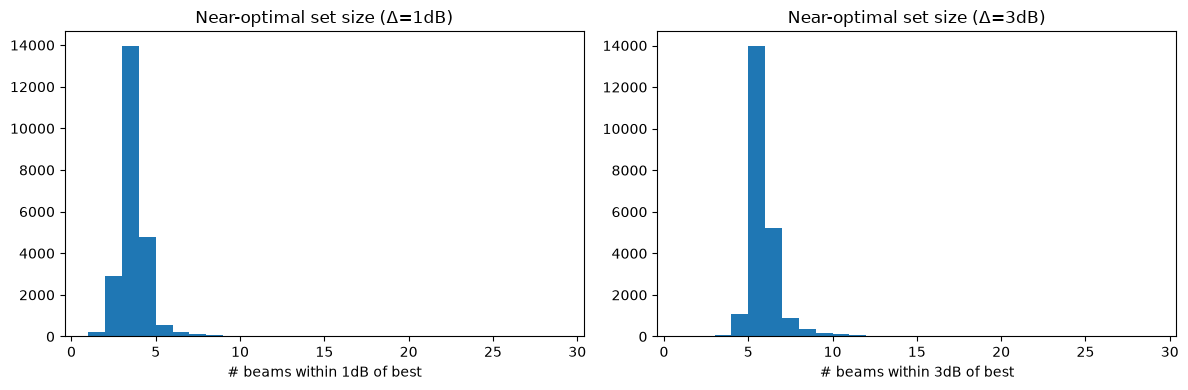

In [22]:
# Cell 17 — The feasibility gate: near-optimal beam set sizes at 1 dB / 3 dB
# This also settles the linear-vs-dB question from Cell 3 by explicitly converting.

import numpy as np
from tqdm import tqdm

def load_full_profile(row):
    """Load all 4 pwr files for one row, concatenate into a 256-length linear power array."""
    vals = []
    for i in range(1, 5):
        p = os.path.join(DATA_ROOT, row[f"unit1_pwr{i}"])
        with open(p, "r") as f:
            vals.extend(float(v) for v in f.readlines())
    return np.array(vals)  # length 256, LINEAR power (confirmed in Cell 3)

# Load every row's full 256-beam profile — this reads ~99,196 files, may take a couple minutes
n_beams_within_1db = []
n_beams_within_3db = []
best_beam_check = []

for idx in tqdm(range(len(df)), desc="Loading power profiles"):
    row = df.iloc[idx]
    linear_profile = load_full_profile(row)

    # Convert linear power -> dB explicitly (this was NEVER done in the old pipeline)
    db_profile = 10 * np.log10(linear_profile)

    best_db = db_profile.max()
    gap_db = best_db - db_profile  # 0 at the best beam, positive everywhere else

    n_beams_within_1db.append((gap_db <= 1.0).sum())
    n_beams_within_3db.append((gap_db <= 3.0).sum())

    # sanity check: does argmax of db_profile match unit1_overall-beam?
    best_beam_check.append(db_profile.argmax() == row["unit1_overall-beam"])

n_beams_within_1db = np.array(n_beams_within_1db)
n_beams_within_3db = np.array(n_beams_within_3db)

print("Sanity check — dB argmax matches unit1_overall-beam for all rows:", all(best_beam_check))

print("\nNumber of beams within 1 dB of optimal, across all rows:")
print(pd.Series(n_beams_within_1db).describe())

print("\nNumber of beams within 3 dB of optimal, across all rows:")
print(pd.Series(n_beams_within_3db).describe())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(n_beams_within_1db, bins=range(1, 30))
axes[0].set_title("Near-optimal set size (Δ=1dB)")
axes[0].set_xlabel("# beams within 1dB of best")
axes[1].hist(n_beams_within_3db, bins=range(1, 30))
axes[1].set_title("Near-optimal set size (Δ=3dB)")
axes[1].set_xlabel("# beams within 3dB of best")
plt.tight_layout()
plt.show()

# Save this so we don't have to re-read 99k files again in future cells
np.save("n_beams_within_1db.npy", n_beams_within_1db)
np.save("n_beams_within_3db.npy", n_beams_within_3db)

**Cell 18 — Investigate the near-optimal blowup outliers.** Isolates the worst-case row and compares its profile shape to a typical one. Result: a genuinely flat/noisy profile with no real peak — a blocked/no-line-of-sight sample, not a data bug.

Rows with >= 10 beams within 1dB of best: 1978 (7.98%)
Rows with >= 20 beams within 1dB of best: 1836 (7.40%)
Rows with >= 50 beams within 1dB of best: 1719 (6.93%)
Rows with >= 100 beams within 1dB of best: 1515 (6.11%)
Rows with >= 150 beams within 1dB of best: 89 (0.36%)

Worst row: idx=14842, abs_index=20107, seq_index=85
Linear power range: 9.131864499067888e-05 to 0.00016845637583173811
dB range: -40.394405413061676 to -37.735125469497675


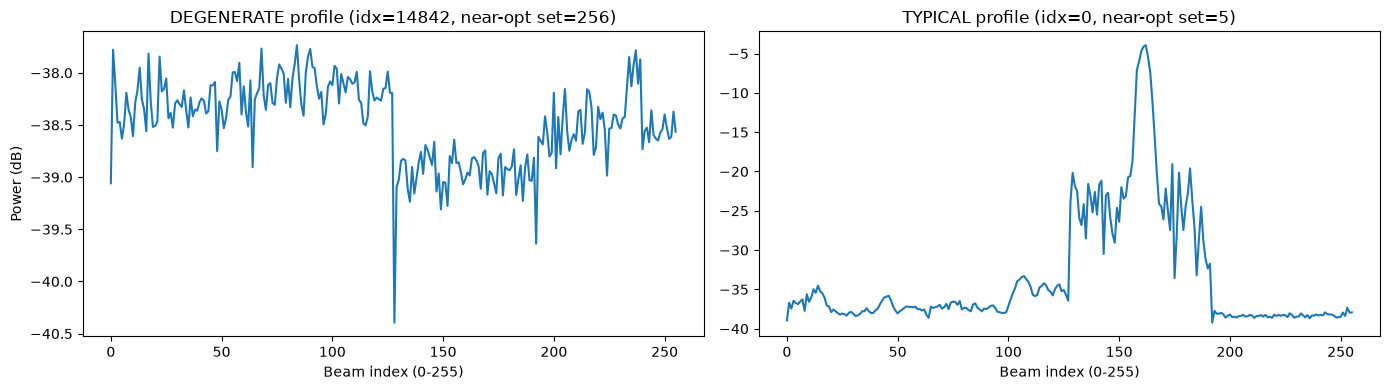

In [23]:
# Cell 18 — Investigate the flat/degenerate profile outliers

# How many rows are "degenerate" at various thresholds?
for thresh in [10, 20, 50, 100, 150]:
    n = (n_beams_within_1db >= thresh).sum()
    print(f"Rows with >= {thresh} beams within 1dB of best: {n} ({100*n/len(df):.2f}%)")

# Look at the single worst row (256 beams within 3dB - completely flat)
worst_idx = np.argmax(n_beams_within_3db)
worst_row = df.iloc[worst_idx]
print(f"\nWorst row: idx={worst_idx}, abs_index={worst_row['abs_index']}, seq_index={worst_row['seq_index']}")

worst_profile_linear = load_full_profile(worst_row)
worst_profile_db = 10 * np.log10(worst_profile_linear)
print("Linear power range:", worst_profile_linear.min(), "to", worst_profile_linear.max())
print("dB range:", worst_profile_db.min(), "to", worst_profile_db.max())

# Plot this flat profile alongside a normal (median) one for comparison
median_like_idx = np.where(n_beams_within_3db == 5)[0][0]
median_row = df.iloc[median_like_idx]
median_profile_db = 10*np.log10(load_full_profile(median_row))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(worst_profile_db)
axes[0].set_title(f"DEGENERATE profile (idx={worst_idx}, near-opt set=256)")
axes[0].set_xlabel("Beam index (0-255)")
axes[0].set_ylabel("Power (dB)")
axes[1].plot(median_profile_db)
axes[1].set_title(f"TYPICAL profile (idx={median_like_idx}, near-opt set=5)")
axes[1].set_xlabel("Beam index (0-255)")
plt.tight_layout()
plt.show()

**Cell 19 — Define a weak-link filter.** Computes dynamic range (max−min beam power in dB) for every row and checks whether it predicts the near-optimal blowup. Result: a sharp elbow around 5-6 dB — real signal, not arbitrary.

Computing dynamic range: 100%|██████████| 24799/24799 [08:50<00:00, 46.74it/s]

Dynamic range (dB) summary:
count    24799.000000
mean        21.955381
std         10.118784
min          1.986159
25%         15.422605
50%         22.925935
75%         29.582630
max         40.329326
dtype: float64


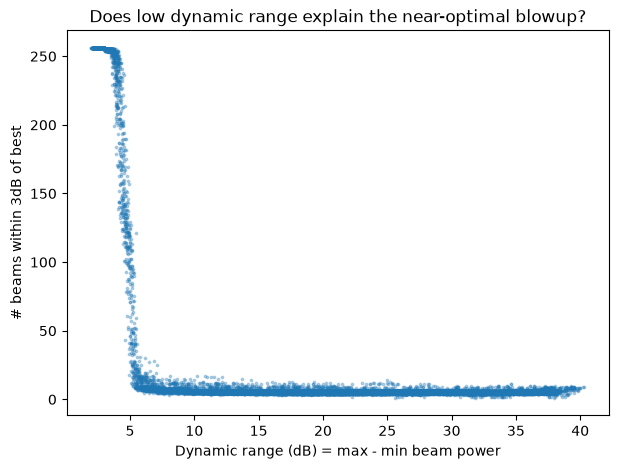

Dynamic range < 5 dB: 2507 rows flagged (10.11%)
Dynamic range < 8 dB: 3230 rows flagged (13.02%)
Dynamic range < 10 dB: 3789 rows flagged (15.28%)
Dynamic range < 12 dB: 4496 rows flagged (18.13%)
Dynamic range < 15 dB: 5956 rows flagged (24.02%)


In [24]:
# Cell 19 — Define and validate a "weak-link" filter based on profile dynamic range

# Dynamic range = strongest beam - weakest beam, in dB. Low range = flat/no-LoS.
# Reuse the loaded profiles where possible; recompute range alongside near-opt counts
dynamic_ranges = []

for idx in tqdm(range(len(df)), desc="Computing dynamic range"):
    row = df.iloc[idx]
    linear_profile = load_full_profile(row)
    db_profile = 10 * np.log10(linear_profile)
    dynamic_ranges.append(db_profile.max() - db_profile.min())

dynamic_ranges = np.array(dynamic_ranges)
np.save("dynamic_ranges_db.npy", dynamic_ranges)

print("Dynamic range (dB) summary:")
print(pd.Series(dynamic_ranges).describe())

# Does low dynamic range actually predict the near-optimal-set blowup? Check correlation directly.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(dynamic_ranges, n_beams_within_3db, s=3, alpha=0.3)
ax.set_xlabel("Dynamic range (dB) = max - min beam power")
ax.set_ylabel("# beams within 3dB of best")
ax.set_title("Does low dynamic range explain the near-optimal blowup?")
plt.show()

# Try a few candidate thresholds and see how many rows each would flag/exclude
for thresh in [5, 8, 10, 12, 15]:
    n_flagged = (dynamic_ranges < thresh).sum()
    print(f"Dynamic range < {thresh} dB: {n_flagged} rows flagged ({100*n_flagged/len(df):.2f}%)")

**Cell 20 — Pin down the exact threshold.** Bins dynamic range finely and tracks median near-optimal-set-size per bin. Result: stabilizes right at 6.0 dB — this becomes the data-driven `WEAK_LINK_THRESHOLD_DB`.

Dynamic range bin (dB) -> median # beams within 3dB, and row count:
  [1.5, 2.0)  n=    2  median_near_opt=256.0
  [2.0, 2.5)  n=  643  median_near_opt=256.0
  [2.5, 3.0)  n=  969  median_near_opt=256.0
  [3.0, 3.5)  n=  328  median_near_opt=255.0
  [3.5, 4.0)  n=  228  median_near_opt=252.0
  [4.0, 4.5)  n=  190  median_near_opt=201.0
  [4.5, 5.0)  n=  147  median_near_opt=122.0
  [5.0, 5.5)  n=  147  median_near_opt=40.0
  [5.5, 6.0)  n=  109  median_near_opt=11.0
  [6.0, 6.5)  n=  126  median_near_opt=8.0
  [6.5, 7.0)  n=  120  median_near_opt=7.0
  [7.0, 7.5)  n=  120  median_near_opt=7.0
  [7.5, 8.0)  n=  101  median_near_opt=7.0
  [8.0, 8.5)  n=  113  median_near_opt=7.0
  [8.5, 9.0)  n=  137  median_near_opt=6.0
  [9.0, 9.5)  n=  149  median_near_opt=6.0
  [9.5, 10.0)  n=  160  median_near_opt=6.0
  [10.0, 10.5)  n=  154  median_near_opt=6.0
  [10.5, 11.0)  n=  148  median_near_opt=6.0
  [11.0, 11.5)  n=  195  median_near_opt=6.0
  [11.5, 12.0)  n=  210  median_near_opt=6.0
  [1

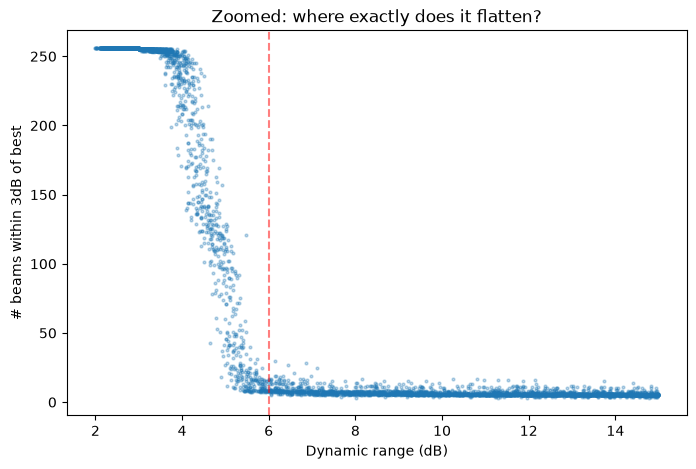

In [25]:
# Cell 20 — Zoom into the elbow to find the actual transition point

# Look at median near-opt-set-size in narrow dynamic-range bins to find where it flattens
bins = np.arange(0, 15, 0.5)
bin_labels = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]
bin_idx = np.digitize(dynamic_ranges, bins)

print("Dynamic range bin (dB) -> median # beams within 3dB, and row count:")
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 0:
        med = np.median(n_beams_within_3db[mask])
        print(f"  [{bins[i-1]:.1f}, {bins[i]:.1f})  n={mask.sum():5d}  median_near_opt={med:.1f}")

# Zoomed scatter, x-axis capped at 15 dB
fig, ax = plt.subplots(figsize=(8,5))
mask_zoom = dynamic_ranges < 15
ax.scatter(dynamic_ranges[mask_zoom], n_beams_within_3db[mask_zoom], s=4, alpha=0.3)
ax.set_xlabel("Dynamic range (dB)")
ax.set_ylabel("# beams within 3dB of best")
ax.set_title("Zoomed: where exactly does it flatten?")
ax.axvline(6, color='red', linestyle='--', alpha=0.5)
plt.show()

**Cell 21 — Finalize and save the weak-link flag.** Applies the 6.0 dB threshold (11.14% of rows flagged), saves to `weak_link_flags.csv`, and checks whether weak-link rows cluster in specific runs (they do — entire runs are 100% weak-link).

In [26]:
# Cell 21 — Finalize the weak-link flag at the data-driven threshold and save it

WEAK_LINK_THRESHOLD_DB = 6.0

weak_link_flag = dynamic_ranges < WEAK_LINK_THRESHOLD_DB
n_weak = weak_link_flag.sum()

print(f"Weak-link threshold: dynamic range < {WEAK_LINK_THRESHOLD_DB} dB")
print(f"Rows flagged as weak-link/blocked: {n_weak} / {len(df)} ({100*n_weak/len(df):.2f}%)")

# Save as a column so it can be joined back to df later, without recomputing
weak_link_df = pd.DataFrame({
    "abs_index": df["abs_index"].values,
    "dynamic_range_db": dynamic_ranges,
    "is_weak_link": weak_link_flag
})
weak_link_df.to_csv("weak_link_flags.csv", index=False)
print("\nSaved to weak_link_flags.csv — joinable on abs_index in later pipeline steps.")

# One more sanity check: is weak-link randomly scattered across the route, 
# or concentrated in specific runs (e.g. a specific stretch with poor RF geometry)?
weak_by_seq = df.groupby("seq_index").apply(lambda g: weak_link_flag[g.index].mean())
print("\nseq_index runs with highest weak-link fraction:")
print(weak_by_seq.sort_values(ascending=False).head(10))

Weak-link threshold: dynamic range < 6.0 dB
Rows flagged as weak-link/blocked: 2763 / 24799 (11.14%)

Saved to weak_link_flags.csv — joinable on abs_index in later pipeline steps.

seq_index runs with highest weak-link fraction:
seq_index
101    1.000
102    1.000
103    1.000
104    1.000
120    1.000
119    0.980
121    0.905
105    0.895
118    0.895
117    0.740
dtype: float64


**Cell 22 — Map where weak-link runs physically sit.** Plots weak-link runs in red on the trajectory. Confirms they cluster along one specific stretch of road, not scattered randomly.

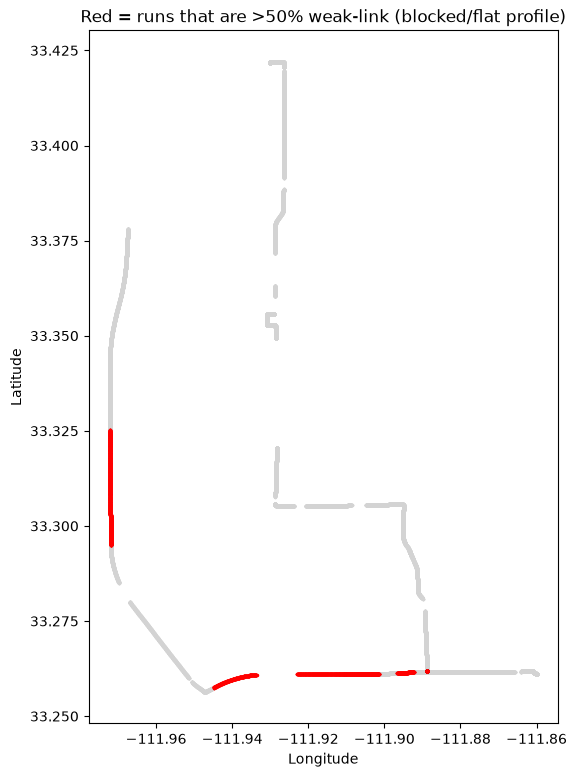

All runs with >50% weak-link fraction:
seq_index
102    1.000
101    1.000
103    1.000
104    1.000
120    1.000
119    0.980
121    0.905
105    0.895
118    0.895
117    0.740
106    0.690
85     0.660
99     0.645
122    0.545
dtype: float64


In [27]:
# Cell 22 — Visualize weak-link runs on the actual trajectory map, to see where they physically sit

fig, ax = plt.subplots(figsize=(9, 9))

weak_seq_ids = weak_by_seq[weak_by_seq > 0.5].index  # runs that are majority weak-link
for sid in df["seq_index"].unique():
    sub = df[df["seq_index"] == sid]
    color = "red" if sid in weak_seq_ids else "lightgray"
    zorder = 2 if sid in weak_seq_ids else 1
    ax.plot(sub["unit1_gps1_lon"], sub["unit1_gps1_lat"], '.', markersize=3, color=color, zorder=zorder)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Red = runs that are >50% weak-link (blocked/flat profile)")
ax.set_aspect("equal")
plt.show()

print("All runs with >50% weak-link fraction:")
print(weak_by_seq[weak_by_seq > 0.5].sort_values(ascending=False))

**Cell 23 — Confirm the physical cause.** Looks at an actual image + inter-vehicle distance inside a weak-link run. Result: target vehicle ~229m away (vs. 8m for a strong sample) on an open rural road — ordinary long-range path-loss physics, not a sensor defect.

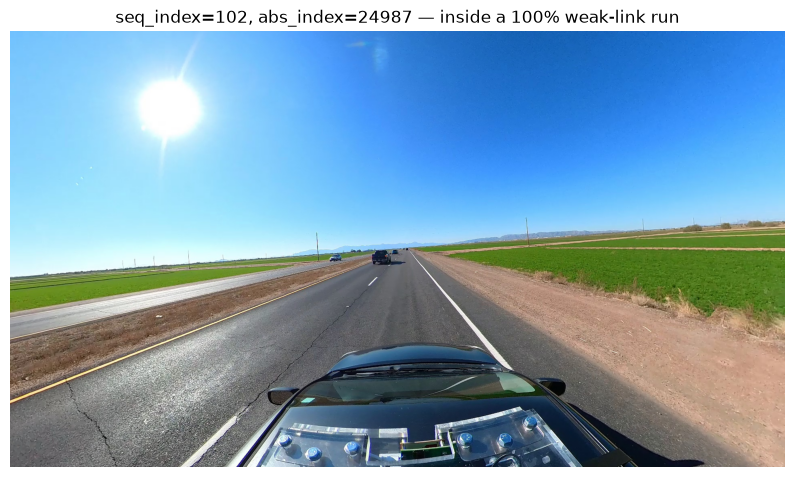

unit1-unit2 distance at this weak-link sample: 228.9 m
unit1-unit2 distance at an earlier strong-link sample: 8.1 m


In [28]:
# Cell 23 — Look at an actual image + profile from inside a weak-link run, to see the real cause

weak_run_id = 102  # 100% weak-link
sample_row_idx = df[df["seq_index"] == weak_run_id].index[len(df[df["seq_index"]==weak_run_id])//2]
sample_row = df.loc[sample_row_idx]

img = Image.open(os.path.join(DATA_ROOT, sample_row["unit1_rgb5"]))
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.title(f"seq_index={weak_run_id}, abs_index={sample_row['abs_index']} — inside a 100% weak-link run")
plt.axis("off")
plt.show()

# Also print distance between unit1 and unit2 for this sample, and for a typical strong-link sample
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2-lat1)
    dlambda = np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

d_weak = haversine_dist(sample_row["unit1_gps1_lat"], sample_row["unit1_gps1_lon"],
                         sample_row["unit2_gps1_lat"], sample_row["unit2_gps1_lon"])
print(f"unit1-unit2 distance at this weak-link sample: {d_weak:.1f} m")

strong_row = df.iloc[0]  # earlier sample, confirmed strong signal
d_strong = haversine_dist(strong_row["unit1_gps1_lat"], strong_row["unit1_gps1_lon"],
                           strong_row["unit2_gps1_lat"], strong_row["unit2_gps1_lon"])
print(f"unit1-unit2 distance at an earlier strong-link sample: {d_strong:.1f} m")

**Cell 24 — Nulls and duplicates.** Checks missing values per column, fully duplicated rows, duplicated `abs_index`, duplicated within-run position, and duplicated file paths. Result: only 7 missing values total (in `unit2_gps1_altitude`), zero duplicates anywhere.

In [ ]:
# Cell 24 — Null values and duplicate rows, checked directly# 1. Null/missing values per columnnull_counts = df.isnull().sum()null_pct = 100 * null_counts / len(df)nulls_report = pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})print("Columns with any missing values:")print(nulls_report[nulls_report["n_missing"] > 0].sort_values("n_missing", ascending=False))if (nulls_report["n_missing"] == 0).all():    print("  None — zero missing values in any column.")# 2. Fully duplicated rows (every column identical)n_dupe_rows = df.duplicated().sum()print(f"\nFully duplicated rows: {n_dupe_rows} / {len(df)}")# 3. Duplicated abs_index (should be unique - it's the primary time key)n_dupe_abs = df["abs_index"].duplicated().sum()print(f"Duplicated abs_index values: {n_dupe_abs} / {len(df)}")# 4. Duplicated (seq_index, within-run position) - i.e. does any row repeat inside a run?df_sorted = df.sort_values("abs_index").reset_index(drop=True)within_run_pos = df_sorted.groupby("seq_index").cumcount()dupe_check = pd.DataFrame({"seq_index": df_sorted["seq_index"], "pos": within_run_pos})n_dupe_pos = dupe_check.duplicated().sum()print(f"Duplicated (seq_index, within-run position) pairs: {n_dupe_pos} / {len(df)}")# 5. Duplicated file pathsfor col in ["unit1_gps1", "unit1_rgb5", "unit1_rgb6", "unit1_pwr1"]:    n_dupe_path = df[col].duplicated().sum()    print(f"Duplicated values in '{col}': {n_dupe_path} / {len(df)}")

Columns with any missing values:
                     n_missing  pct_missing
unit2_gps1_altitude          7     0.028227
Fully duplicated rows: 0 / 24799
Duplicated abs_index values: 0 / 24799
Duplicated (seq_index, within-run position) pairs: 0 / 24799
Duplicated values in 'unit1_gps1': 0 / 24799
Duplicated values in 'unit1_rgb5': 0 / 24799
Duplicated values in 'unit1_rgb6': 0 / 24799
Duplicated values in 'unit1_pwr1': 0 / 24799


**Cell 25 — Are the missing-altitude rows the known HDOP-dip rows?** Confirms the 7 missing-altitude rows are the exact same 7 rows flagged for degraded HDOP in Cell 15/16 — same root cause, already fully explained, no action needed.

In [ ]:
# Cell 25 — Are the missing-altitude rows the same 7 rows as the degraded-HDOP rows?missing_alt_idx = set(df[df["unit2_gps1_altitude"].isnull()].index)bad_hdop_idx = set(df[df["unit2_gps1_hdop"] > 2].index)print("Missing-altitude row indices:", sorted(missing_alt_idx))print("Degraded-HDOP row indices:   ", sorted(bad_hdop_idx))print("Are they the same set of rows?", missing_alt_idx == bad_hdop_idx)

Missing-altitude row indices: [19951, 19952, 19953, 19954, 19955, 19956, 19957]
Degraded-HDOP row indices:    [19951, 19952, 19953, 19954, 19955, 19956, 19957]
Are they the same set of rows? True
